#📌 Extracción

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import requests
import warnings
warnings.filterwarnings('ignore')

In [11]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
raw_data = response.json()

print(f"✅ Datos cargados: {len(raw_data)} registros")
print("\nEstructura de un registro de ejemplo:")
print(json.dumps(raw_data[0], indent=2))

✅ Datos cargados: 7267 registros

Estructura de un registro de ejemplo:
{
  "customerID": "0002-ORFBO",
  "Churn": "No",
  "customer": {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "Yes",
    "tenure": 9
  },
  "phone": {
    "PhoneService": "Yes",
    "MultipleLines": "No"
  },
  "internet": {
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "Yes",
    "StreamingTV": "Yes",
    "StreamingMovies": "No"
  },
  "account": {
    "Contract": "One year",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Mailed check",
    "Charges": {
      "Monthly": 65.6,
      "Total": "593.3"
    }
  }
}


In [12]:
df = pd.json_normalize(raw_data)

print(f"✅ DataFrame creado: {df.shape[0]} filas × {df.shape[1]} columnas")
print("\nColumnas:")
print(df.columns.tolist())
df.head(3)

✅ DataFrame creado: 7267 filas × 21 columnas

Columnas:
['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


#🔧 Transformación

In [13]:
print("=== INFORMACIÓN GENERAL ===")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print()
df.info()

=== INFORMACIÓN GENERAL ===
Filas: 7267 | Columnas: 21

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   objec

In [14]:
print("=== TIPOS DE DATO ===")
print(df.dtypes)

=== TIPOS DE DATO ===
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object


In [15]:
print("=== VISTA PREVIA ===")
df.head()

=== VISTA PREVIA ===


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [16]:
print("=== VALORES ÚNICOS POR COLUMNA ===")
for col in df.columns:
    unicos = df[col].unique()
    print(f"\n🔹 {col} ({df[col].dtype}) — {df[col].nunique()} únicos:")
    print(f"   {unicos[:6]}{'...' if len(unicos) > 6 else ''}")

=== VALORES ÚNICOS POR COLUMNA ===

🔹 customerID (object) — 7267 únicos:
   ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' '0011-IGKFF' '0013-EXCHZ'
 '0013-MHZWF']...

🔹 Churn (object) — 3 únicos:
   ['No' 'Yes' '']

🔹 customer.gender (object) — 2 únicos:
   ['Female' 'Male']

🔹 customer.SeniorCitizen (int64) — 2 únicos:
   [0 1]

🔹 customer.Partner (object) — 2 únicos:
   ['Yes' 'No']

🔹 customer.Dependents (object) — 2 únicos:
   ['Yes' 'No']

🔹 customer.tenure (int64) — 73 únicos:
   [ 9  4 13  3 71 63]...

🔹 phone.PhoneService (object) — 2 únicos:
   ['Yes' 'No']

🔹 phone.MultipleLines (object) — 3 únicos:
   ['No' 'Yes' 'No phone service']

🔹 internet.InternetService (object) — 3 únicos:
   ['DSL' 'Fiber optic' 'No']

🔹 internet.OnlineSecurity (object) — 3 únicos:
   ['No' 'Yes' 'No internet service']

🔹 internet.OnlineBackup (object) — 3 únicos:
   ['Yes' 'No' 'No internet service']

🔹 internet.DeviceProtection (object) — 3 únicos:
   ['No' 'Yes' 'No internet service']

🔹 internet.TechS

In [17]:
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.describe()

=== ESTADÍSTICAS DESCRIPTIVAS ===


,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [18]:
print("=== VALORES NULOS ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "✅ No hay valores nulos")

=== VALORES NULOS ===
✅ No hay valores nulos


In [19]:
print("=== VALORES VACÍOS (strings) ===")
for col in df.select_dtypes(include='object').columns:
    n_empty = (df[col] == '').sum()
    n_spaces = (df[col] == ' ').sum()
    if n_empty > 0 or n_spaces > 0:
        print(f"  🔸 {col}: {n_empty} vacíos, {n_spaces} solo espacios")

print("✅ Revisión completada")

=== VALORES VACÍOS (strings) ===
  🔸 Churn: 224 vacíos, 0 solo espacios
  🔸 account.Charges.Total: 0 vacíos, 11 solo espacios
✅ Revisión completada


In [20]:
print("=== DUPLICADOS ===")
duplicados = df.duplicated().sum()
print(f"  Filas duplicadas: {duplicados}")

# Verificar duplicados por customerID
dup_id = df['customerID'].duplicated().sum()
print(f"  customerID duplicados: {dup_id}")

=== DUPLICADOS ===
  Filas duplicadas: 0
  customerID duplicados: 0


In [21]:
print("=== VALORES ÚNICOS EN CHURN ===")
print(df['Churn'].value_counts(dropna=False))

print(f"\n  Registros con Churn vacío: {(df['Churn'] == '').sum()}")

=== VALORES ÚNICOS EN CHURN ===
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

  Registros con Churn vacío: 224


In [22]:
print("=== REVISIÓN DE account.Charges.Total ===")
print(f"  Tipo de dato: {df['account.Charges.Total'].dtype}")
print(f"  Valores no convertibles a número:")

errores = pd.to_numeric(df['account.Charges.Total'], errors='coerce').isna()
print(f"  Total: {errores.sum()}")
print(df.loc[errores, ['customerID', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']].head(10))

=== REVISIÓN DE account.Charges.Total ===
  Tipo de dato: object
  Valores no convertibles a número:
  Total: 11
      customerID  customer.tenure  account.Charges.Monthly  \
975   1371-DWPAZ                0                    56.05   
1775  2520-SGTTA                0                    20.00   
1955  2775-SEFEE                0                    61.90   
2075  2923-ARZLG                0                    19.70   
2232  3115-CZMZD                0                    20.25   
2308  3213-VVOLG                0                    25.35   
2930  4075-WKNIU                0                    73.35   
3134  4367-NUYAO                0                    25.75   
3203  4472-LVYGI                0                    52.55   
4169  5709-LVOEQ                0                    80.85   

     account.Charges.Total  
975                         
1775                        
1955                        
2075                        
2232                        
2308                        
2

In [23]:
print(f"Registros antes: {len(df)}")

df = df[df['Churn'] != ''].copy()

print(f"Registros después: {len(df)}")
print(f"✅ Eliminados: 224 registros sin clasificación de Churn")

Registros antes: 7267
Registros después: 7043
✅ Eliminados: 224 registros sin clasificación de Churn


In [24]:
# Convertir a numérico
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Imputar los NaN con MonthlyCharges × tenure
mask = df['account.Charges.Total'].isna()
df.loc[mask, 'account.Charges.Total'] = (
    df.loc[mask, 'account.Charges.Monthly'] * df.loc[mask, 'customer.tenure']
)

print(f"✅ Valores imputados: {mask.sum()}")
print(f"   NaN restantes: {df['account.Charges.Total'].isna().sum()}")

✅ Valores imputados: 11
   NaN restantes: 0


In [26]:
df.rename(columns={
    'customer.gender':            'gender',
    'customer.SeniorCitizen':     'SeniorCitizen',
    'customer.Partner':           'Partner',
    'customer.Dependents':        'Dependents',
    'customer.tenure':            'tenure',
    'phone.PhoneService':         'PhoneService',
    'phone.MultipleLines':        'MultipleLines',
    'internet.InternetService':   'InternetService',
    'internet.OnlineSecurity':    'OnlineSecurity',
    'internet.OnlineBackup':      'OnlineBackup',
    'internet.DeviceProtection':  'DeviceProtection',
    'internet.TechSupport':       'TechSupport',
    'internet.StreamingTV':       'StreamingTV',
    'internet.StreamingMovies':   'StreamingMovies',
    'account.Contract':           'Contract',
    'account.PaperlessBilling':   'PaperlessBilling',
    'account.PaymentMethod':      'PaymentMethod',
    'account.Charges.Monthly':    'MonthlyCharges',
    'account.Charges.Total':      'TotalCharges',
}, inplace=True)

print("✅ Columnas renombradas:")
print(df.columns.tolist())

✅ Columnas renombradas:
['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [27]:
print("=== VERIFICACIÓN FINAL ===")
print(f"  Filas:    {df.shape[0]}")
print(f"  Columnas: {df.shape[1]}")
print(f"  Nulos:    {df.isnull().sum().sum()}")
print(f"  Duplicados: {df.duplicated().sum()}")
print()
print("=== TIPOS DE DATO ===")
print(df.dtypes)

=== VERIFICACIÓN FINAL ===
  Filas:    7043
  Columnas: 21
  Nulos:    0
  Duplicados: 0

=== TIPOS DE DATO ===
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
dtype: object


In [28]:
df['DailyCharges'] = (df['MonthlyCharges'] / 30).round(2)

print("✅ Columna 'DailyCharges' creada")
print()
print(df[['customerID', 'MonthlyCharges', 'DailyCharges']].head(10))

✅ Columna 'DailyCharges' creada

   customerID  MonthlyCharges  DailyCharges
0  0002-ORFBO           65.60          2.19
1  0003-MKNFE           59.90          2.00
2  0004-TLHLJ           73.90          2.46
3  0011-IGKFF           98.00          3.27
4  0013-EXCHZ           83.90          2.80
5  0013-MHZWF           69.40          2.31
6  0013-SMEOE          109.70          3.66
7  0014-BMAQU           84.65          2.82
8  0015-UOCOJ           48.20          1.61
9  0016-QLJIS           90.45          3.02


In [29]:
print("=== ESTADÍSTICAS DE DailyCharges ===")
print(df['DailyCharges'].describe().round(2))
print()
print(f"  Cargo diario mínimo:  ${df['DailyCharges'].min()}")
print(f"  Cargo diario máximo:  ${df['DailyCharges'].max()}")
print(f"  Cargo diario promedio: ${df['DailyCharges'].mean():.2f}")

=== ESTADÍSTICAS DE DailyCharges ===
count    7043.00
mean        2.16
std         1.00
min         0.61
25%         1.18
50%         2.34
75%         2.99
max         3.96
Name: DailyCharges, dtype: float64

  Cargo diario mínimo:  $0.61
  Cargo diario máximo:  $3.96
  Cargo diario promedio: $2.16


#📊 Carga y análisis

In [30]:
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'DailyCharges']].describe().round(2)

=== ESTADÍSTICAS DESCRIPTIVAS ===


,tenure,MonthlyCharges,TotalCharges,DailyCharges
count,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73,2.16
std,24.56,30.09,2266.79,1.00
min,0.00,18.25,0.00,0.61
25%,9.00,35.50,398.55,1.18
50%,29.00,70.35,1394.55,2.34
75%,55.00,89.85,3786.60,2.99
max,72.00,118.75,8684.80,3.96


In [31]:
print("=== MEDIA POR GRUPO DE CHURN ===")
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges', 'DailyCharges']].mean().round(2)

=== MEDIA POR GRUPO DE CHURN ===


,tenure,MonthlyCharges,TotalCharges,DailyCharges
Churn,,,,
No,37.57,61.27,2549.91,2.04
Yes,17.98,74.44,1531.80,2.48


In [32]:
print("=== MEDIANA ===")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'DailyCharges']].median().round(2))

print("\n=== DESVIACIÓN ESTÁNDAR ===")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'DailyCharges']].std().round(2))

=== MEDIANA ===
tenure              29.00
MonthlyCharges      70.35
TotalCharges      1394.55
DailyCharges         2.34
dtype: float64

=== DESVIACIÓN ESTÁNDAR ===
tenure              24.56
MonthlyCharges      30.09
TotalCharges      2266.79
DailyCharges         1.00
dtype: float64


In [34]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'Contract', 'PaymentMethod', 'InternetService']

for col in cat_cols:
    print(f"\n🔹 {col}:")
    print(df[col].value_counts())


🔹 gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

🔹 SeniorCitizen:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

🔹 Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

🔹 Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

🔹 Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

🔹 PaymentMethod:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

🔹 InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


In [35]:
print("=== DISTRIBUCIÓN DE CHURN ===")
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

=== DISTRIBUCIÓN DE CHURN ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5%
Yes    26.5%
Name: proportion, dtype: object


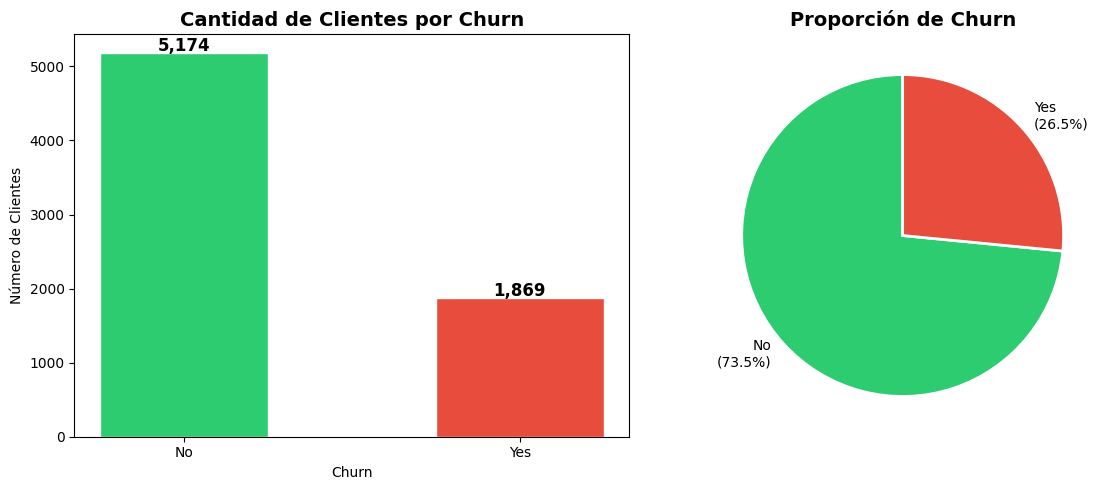

In [36]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100
COLORS = {'No': '#2ecc71', 'Yes': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barras
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=[COLORS[c] for c in churn_counts.index],
                   edgecolor='white', width=0.5)
axes[0].set_title('Cantidad de Clientes por Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Número de Clientes')
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')

# Pie
axes[1].pie(churn_pct.values,
            labels=[f'{k}\n({v:.1f}%)' for k, v in zip(churn_pct.index, churn_pct.values)],
            colors=[COLORS[c] for c in churn_pct.index],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [38]:
cat_vars = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'Contract', 'PaymentMethod', 'InternetService',
            'PaperlessBilling', 'PhoneService']

print("=== TASA DE CHURN POR VARIABLE CATEGÓRICA ===\n")
for col in cat_vars:
    tabla = df.groupby(col)['Churn'].value_counts(normalize=True).mul(100).round(1).unstack()
    print(f"🔹 {col}:")
    print(tabla)
    print()

=== TASA DE CHURN POR VARIABLE CATEGÓRICA ===

🔹 gender:
Churn     No   Yes
gender            
Female  73.1  26.9
Male    73.8  26.2

🔹 SeniorCitizen:
Churn            No   Yes
SeniorCitizen            
0              76.4  23.6
1              58.3  41.7

🔹 Partner:
Churn      No   Yes
Partner            
No       67.0  33.0
Yes      80.3  19.7

🔹 Dependents:
Churn         No   Yes
Dependents            
No          68.7  31.3
Yes         84.5  15.5

🔹 Contract:
Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8

🔹 PaymentMethod:
Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  83.3  16.7
Credit card (automatic)    84.8  15.2
Electronic check           54.7  45.3
Mailed check               80.9  19.1

🔹 InternetService:
Churn              No   Yes
InternetService            
DSL              81.0  19.0
Fiber optic      58.1  41.9
No               92.

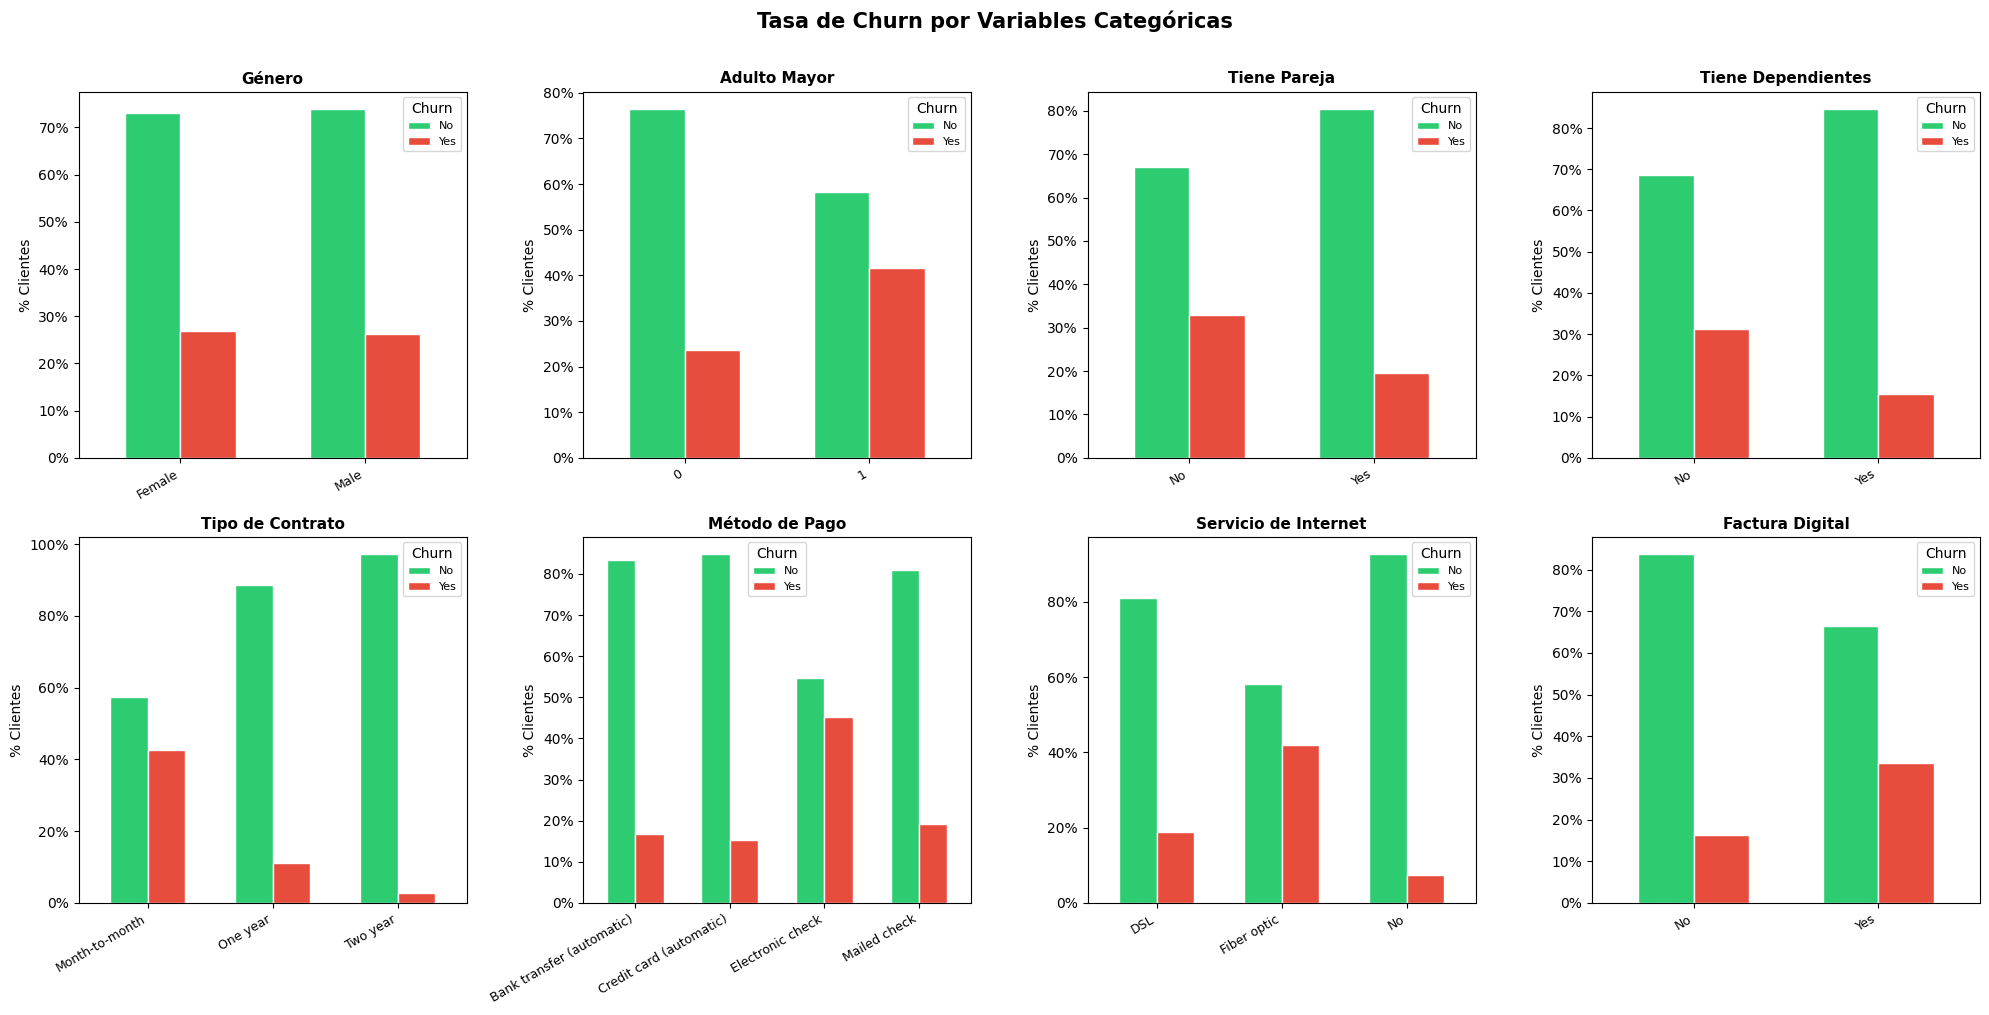

In [39]:
import matplotlib.ticker as mticker

cat_vars = [
    ('gender',           'Género'),
    ('SeniorCitizen',    'Adulto Mayor'),
    ('Partner',          'Tiene Pareja'),
    ('Dependents',       'Tiene Dependientes'),
    ('Contract',         'Tipo de Contrato'),
    ('PaymentMethod',    'Método de Pago'),
    ('InternetService',  'Servicio de Internet'),
    ('PaperlessBilling', 'Factura Digital'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (col, title) in zip(axes, cat_vars):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct[['No', 'Yes']].plot(kind='bar', ax=ax,
                           color=[COLORS['No'], COLORS['Yes']],
                           edgecolor='white', width=0.6)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('% Clientes')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    ax.legend(title='Churn', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.suptitle('Tasa de Churn por Variables Categóricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

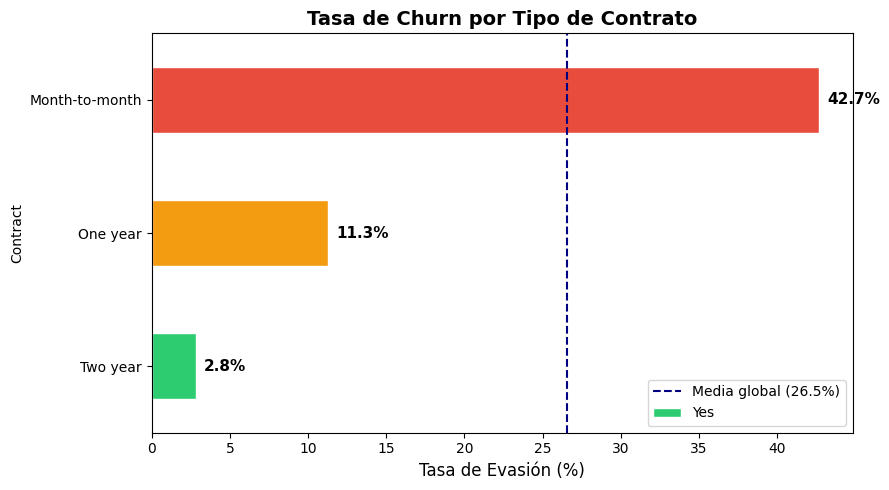

In [40]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).mul(100).round(1).unstack()

fig, ax = plt.subplots(figsize=(9, 5))
contract_churn['Yes'].sort_values(ascending=True).plot(
    kind='barh', ax=ax,
    color=['#2ecc71', '#f39c12', '#e74c3c'],
    edgecolor='white')

ax.set_xlabel('Tasa de Evasión (%)', fontsize=12)
ax.set_title('Tasa de Churn por Tipo de Contrato', fontsize=14, fontweight='bold')
ax.axvline(df['Churn'].eq('Yes').mean() * 100, color='navy',
           linestyle='--', label=f"Media global ({df['Churn'].eq('Yes').mean()*100:.1f}%)")
ax.legend()

for i, val in enumerate(contract_churn['Yes'].sort_values(ascending=True)):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

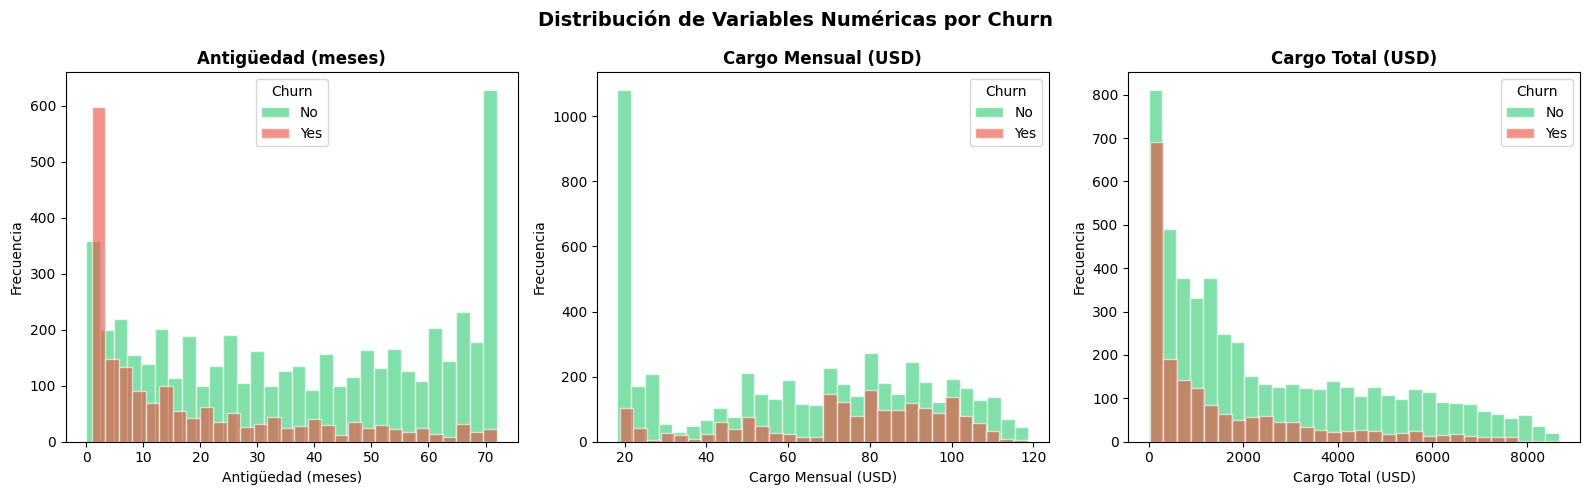

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

num_vars = [
    ('tenure',         'Antigüedad (meses)'),
    ('MonthlyCharges', 'Cargo Mensual (USD)'),
    ('TotalCharges',   'Cargo Total (USD)'),
]

for ax, (var, label) in zip(axes, num_vars):
    for churn_val, color in COLORS.items():
        subset = df[df['Churn'] == churn_val][var]
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label=churn_val, edgecolor='white')
    ax.set_title(f'{label}', fontsize=12, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend(title='Churn')

plt.suptitle('Distribución de Variables Numéricas por Churn',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

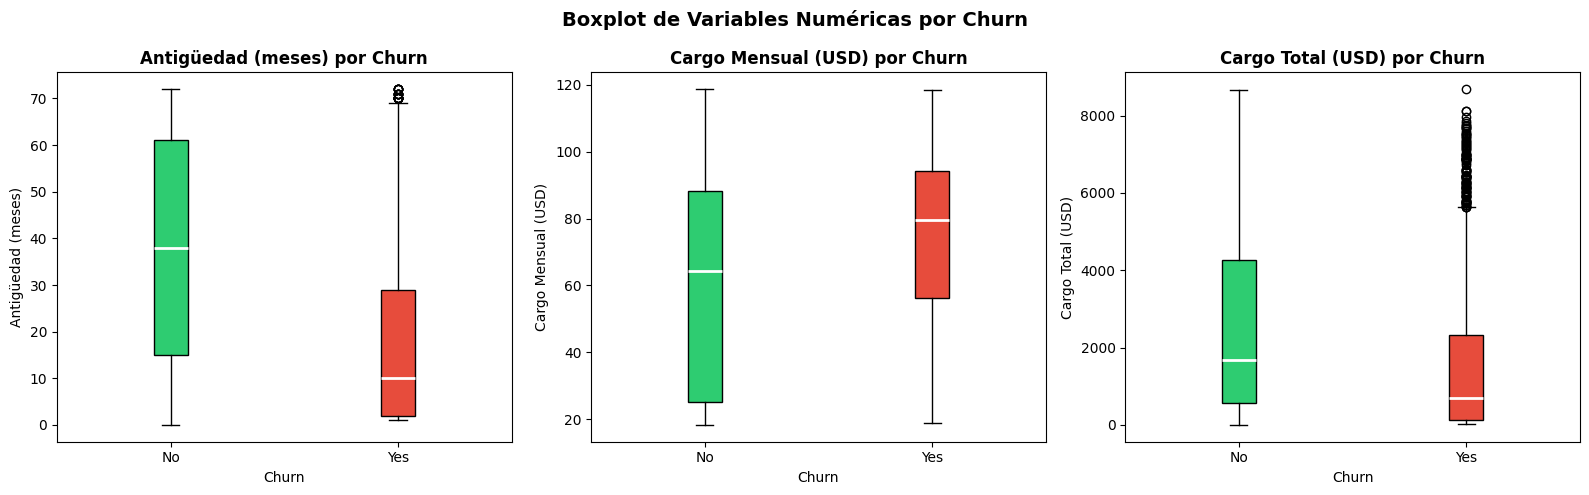

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, label) in zip(axes, [
    ('tenure',         'Antigüedad (meses)'),
    ('MonthlyCharges', 'Cargo Mensual (USD)'),
    ('TotalCharges',   'Cargo Total (USD)'),
]):
    data_no  = df[df['Churn'] == 'No'][col]
    data_yes = df[df['Churn'] == 'Yes'][col]

    bp = ax.boxplot([data_no, data_yes], labels=['No', 'Yes'], patch_artist=True,
                    medianprops=dict(color='white', linewidth=2))

    bp['boxes'][0].set_facecolor(COLORS['No'])
    bp['boxes'][1].set_facecolor(COLORS['Yes'])

    ax.set_title(f'{label} por Churn', fontsize=12, fontweight='bold')
    ax.set_xlabel('Churn')
    ax.set_ylabel(label)

plt.suptitle('Boxplot de Variables Numéricas por Churn',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

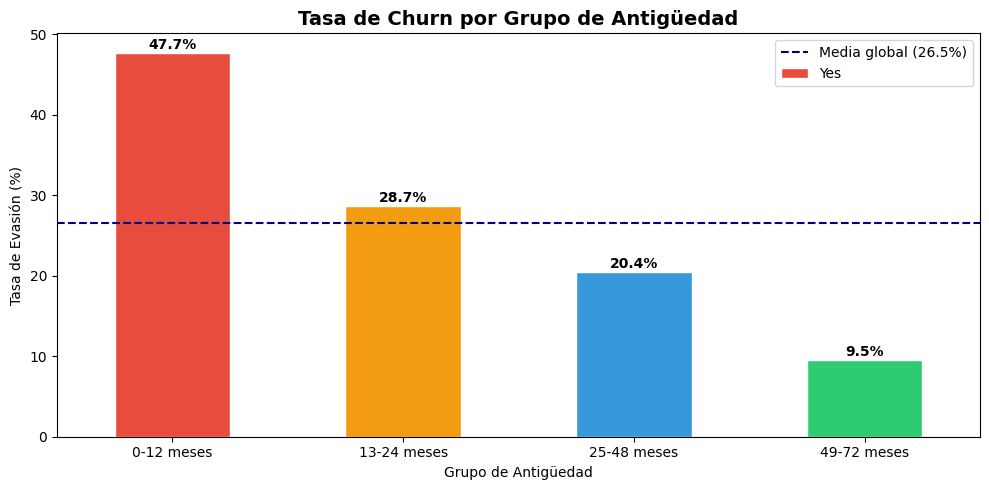

In [43]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 meses', '13-24 meses', '25-48 meses', '49-72 meses']
)

tenure_churn = df.groupby('TenureGroup', observed=True)['Churn'].value_counts(
    normalize=True).mul(100).round(1).unstack()

fig, ax = plt.subplots(figsize=(10, 5))
tenure_churn['Yes'].plot(
    kind='bar', ax=ax,
    color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'],
    edgecolor='white', width=0.5)

ax.set_title('Tasa de Churn por Grupo de Antigüedad', fontsize=14, fontweight='bold')
ax.set_xlabel('Grupo de Antigüedad')
ax.set_ylabel('Tasa de Evasión (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.axhline(df['Churn'].eq('Yes').mean() * 100, color='navy',
           linestyle='--', label=f"Media global ({df['Churn'].eq('Yes').mean()*100:.1f}%)")
ax.legend()

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [44]:
print("=== PROMEDIO DE VARIABLES NUMÉRICAS POR CHURN ===")
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges', 'DailyCharges']].mean().round(2)

=== PROMEDIO DE VARIABLES NUMÉRICAS POR CHURN ===


,tenure,MonthlyCharges,TotalCharges,DailyCharges
Churn,,,,
No,37.57,61.27,2549.91,2.04
Yes,17.98,74.44,1531.80,2.48


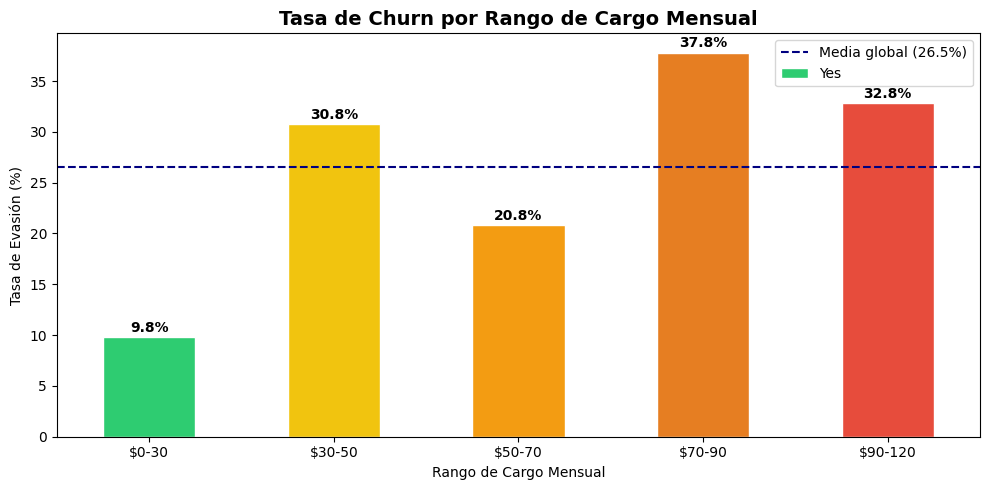

In [45]:
# Crear rangos de cargo mensual
df['MonthlyGroup'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 30, 50, 70, 90, 120],
    labels=['$0-30', '$30-50', '$50-70', '$70-90', '$90-120']
)

monthly_churn = df.groupby('MonthlyGroup', observed=True)['Churn'].value_counts(
    normalize=True).mul(100).round(1).unstack()

fig, ax = plt.subplots(figsize=(10, 5))
monthly_churn['Yes'].plot(
    kind='bar', ax=ax,
    color=['#2ecc71', '#f1c40f', '#f39c12', '#e67e22', '#e74c3c'],
    edgecolor='white', width=0.5)

ax.set_title('Tasa de Churn por Rango de Cargo Mensual', fontsize=14, fontweight='bold')
ax.set_xlabel('Rango de Cargo Mensual')
ax.set_ylabel('Tasa de Evasión (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.axhline(df['Churn'].eq('Yes').mean() * 100, color='navy',
           linestyle='--', label=f"Media global ({df['Churn'].eq('Yes').mean()*100:.1f}%)")
ax.legend()

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

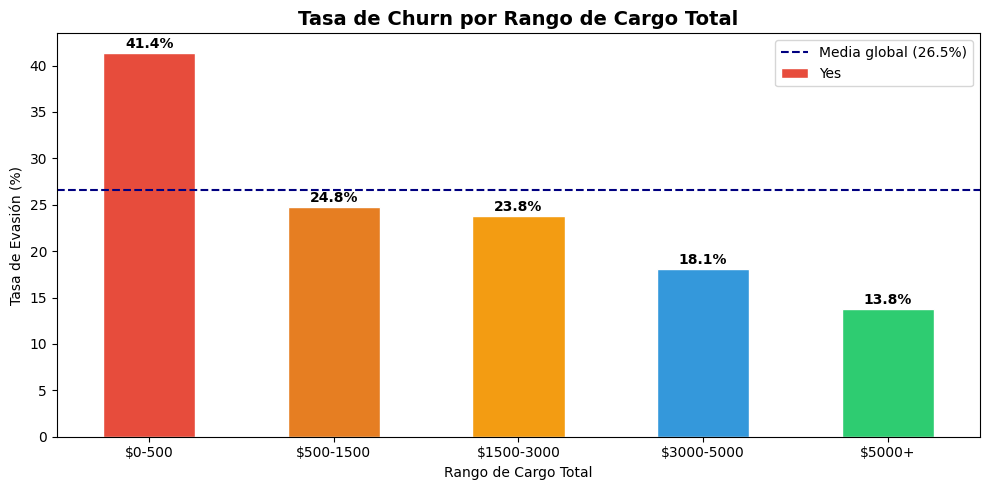

In [46]:
df['TotalGroup'] = pd.cut(
    df['TotalCharges'],
    bins=[0, 500, 1500, 3000, 5000, 9000],
    labels=['$0-500', '$500-1500', '$1500-3000', '$3000-5000', '$5000+']
)

total_churn = df.groupby('TotalGroup', observed=True)['Churn'].value_counts(
    normalize=True).mul(100).round(1).unstack()

fig, ax = plt.subplots(figsize=(10, 5))
total_churn['Yes'].plot(
    kind='bar', ax=ax,
    color=['#e74c3c', '#e67e22', '#f39c12', '#3498db', '#2ecc71'],
    edgecolor='white', width=0.5)

ax.set_title('Tasa de Churn por Rango de Cargo Total', fontsize=14, fontweight='bold')
ax.set_xlabel('Rango de Cargo Total')
ax.set_ylabel('Tasa de Evasión (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.axhline(df['Churn'].eq('Yes').mean() * 100, color='navy',
           linestyle='--', label=f"Media global ({df['Churn'].eq('Yes').mean()*100:.1f}%)")
ax.legend()

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

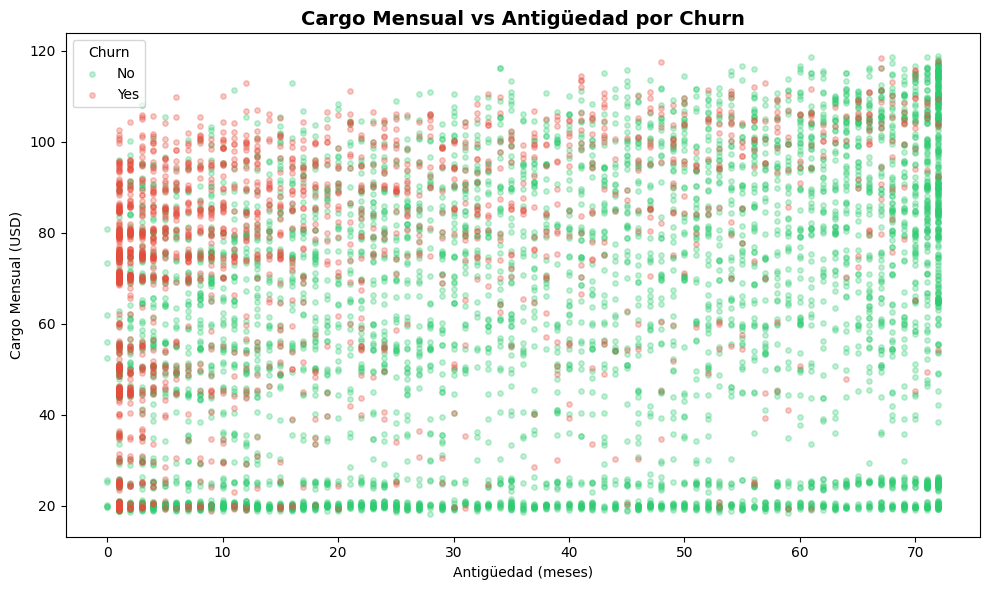

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))

for churn_val, color in COLORS.items():
    subset = df[df['Churn'] == churn_val]
    ax.scatter(subset['tenure'], subset['MonthlyCharges'],
               alpha=0.3, color=color, label=churn_val, s=15)

ax.set_title('Cargo Mensual vs Antigüedad por Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Antigüedad (meses)')
ax.set_ylabel('Cargo Mensual (USD)')
ax.legend(title='Churn')
plt.tight_layout()
plt.show()

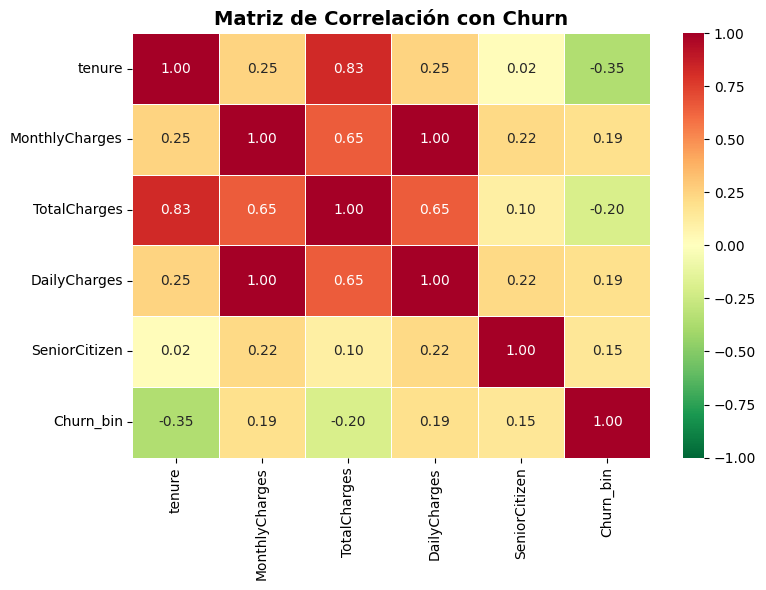

In [48]:
df_corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'DailyCharges', 'SeniorCitizen']].copy()
df_corr['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, vmin=-1, vmax=1, ax=ax)
ax.set_title('Matriz de Correlación con Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#📄Informe final

In [53]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║           INFORME FINAL — ANÁLISIS DE CHURN TELECOM X           ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║           INFORME FINAL — ANÁLISIS DE CHURN TELECOM X           ║
╚══════════════════════════════════════════════════════════════════╝



## 📋 1. Introducción

TelecomX enfrenta una **tasa de evasión (churn) del 26.5%** sobre un total
de 7,043 clientes analizados. Este nivel de cancelaciones representa una
pérdida significativa de ingresos recurrentes y exige comprender a fondo
los factores que llevan a los clientes a abandonar el servicio.

**Objetivo del análisis:**
Recopilar, limpiar y explorar los datos de clientes para identificar
patrones de evasión que permitan al equipo de Data Science construir
modelos predictivos y al negocio tomar decisiones estratégicas de retención.

## 🔧 2. Limpieza y Tratamiento de Datos

| Acción | Detalle |
|---|---|
| Carga de datos | JSON consumido desde API de GitHub con `requests` |
| Aplanamiento | Estructura anidada convertida a tabla plana con `pd.json_normalize()` |
| Churn vacío | 224 registros sin clasificación eliminados |
| TotalCharges | Convertida de `string` a `float`; 11 NaN imputados con `MonthlyCharges × tenure` |
| Renombrado | Columnas con prefijos (`customer.`, `account.`) simplificadas |
| Nueva variable | `DailyCharges` = MonthlyCharges / 30 |
| Nueva variable | `TenureGroup` — segmentos de antigüedad (0-12, 13-24, 25-48, 49-72 meses) |
| Nueva variable | `MonthlyGroup` y `TotalGroup` — rangos de cargos para análisis visual |

In [56]:
print("=== RESUMEN EJECUTIVO ===\n")

total     = len(df)
churn_n   = df['Churn'].eq('Yes').sum()
churn_pct = churn_n / total * 100

print(f"  Total clientes analizados : {total:,}")
print(f"  Clientes que cancelaron   : {churn_n:,} ({churn_pct:.1f}%)")
print(f"  Clientes que permanecieron: {total - churn_n:,} ({100 - churn_pct:.1f}%)")

print("\n--- Cargo mensual promedio ---")
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

print("\n--- Antigüedad promedio (meses) ---")
print(df.groupby('Churn')['tenure'].mean().round(1))

print("\n--- Churn por tipo de contrato ---")
print(df.groupby('Contract')['Churn'].value_counts(normalize=True)
      .mul(100).round(1).unstack()[['Yes','No']])

print("\n--- Churn por servicio de internet ---")
print(df.groupby('InternetService')['Churn'].value_counts(normalize=True)
      .mul(100).round(1).unstack()[['Yes','No']])

print("\n--- Churn por método de pago ---")
print(df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True)
      .mul(100).round(1).unstack()[['Yes','No']])

=== RESUMEN EJECUTIVO ===

  Total clientes analizados : 7,043
  Clientes que cancelaron   : 1,869 (26.5%)
  Clientes que permanecieron: 5,174 (73.5%)

--- Cargo mensual promedio ---
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

--- Antigüedad promedio (meses) ---
Churn
No     37.6
Yes    18.0
Name: tenure, dtype: float64

--- Churn por tipo de contrato ---
Churn            Yes    No
Contract                  
Month-to-month  42.7  57.3
One year        11.3  88.7
Two year         2.8  97.2

--- Churn por servicio de internet ---
Churn             Yes    No
InternetService            
DSL              19.0  81.0
Fiber optic      41.9  58.1
No                7.4  92.6

--- Churn por método de pago ---
Churn                       Yes    No
PaymentMethod                        
Bank transfer (automatic)  16.7  83.3
Credit card (automatic)    15.2  84.8
Electronic check           45.3  54.7
Mailed check               19.1  80.9


Celda de texto:
```
## 💡 3. Conclusiones e Insights

### 🔴 Factores de alto riesgo identificados

**1. Tipo de contrato — el factor más crítico**
Los clientes con contrato **mes a mes** presentan una tasa de churn del ~42.7%,
frente al ~11% anual y ~2.8% bianual. La ausencia de compromiso a largo plazo
es el predictor más fuerte de abandono.

**2. Clientes nuevos (0-12 meses) en zona de peligro**
Cerca del 47% de los clientes con menos de 12 meses cancelan el servicio.
Pasado el primer año la retención mejora considerablemente, lo que señala
una etapa crítica de onboarding.

**3. Cargos mensuales elevados**
Los clientes que se van pagan en promedio **$74.44/mes** versus **$61.27/mes**
de quienes permanecen. La percepción de costo-beneficio es un factor relevante.

**4. Fibra óptica con alta evasión**
A pesar de ser el servicio premium, los clientes de Fiber Optic muestran
mayor churn que los de DSL, lo que puede indicar problemas de calidad
o expectativas no cumplidas.

**5. Cheque electrónico como señal de alerta**
Es el método de pago con mayor tasa de evasión, asociado a clientes
menos comprometidos con la empresa.

**6. Adultos mayores más vulnerables**
Aunque son minoría, su tasa de churn es superior al promedio, posiblemente
por dificultades de usabilidad o falta de planes adecuados a su perfil.
```

---

## 🚀 4. Recomendaciones Estratégicas

| # | Acción | Impacto esperado |
|---|---|---|
| 1 | **Incentivar contratos anuales/bianuales** con descuentos o beneficios exclusivos para clientes mes a mes | 🔴 Alto |
| 2 | **Programa de onboarding (primeros 12 meses)** con seguimiento proactivo y ofertas de fidelización | 🔴 Alto |
| 3 | **Revisar calidad del servicio de Fibra Óptica** analizando tickets de soporte y NPS por segmento | 🟠 Medio |
| 4 | **Bundling de TechSupport y OnlineSecurity** como parte de planes base para aumentar retención | 🟠 Medio |
| 5 | **Plan diferenciado para adultos mayores** con soporte prioritario y facturación simplificada | 🟡 Medio |
| 6 | **Migrar clientes de cheque electrónico** a débito automático con incentivos de descuento | 🟡 Medio |

In [57]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║                   ANÁLISIS COMPLETADO ✅                        ║
║                                                                  ║
║  Dataset    : 7,043 clientes   Churn rate : 26.5%               ║
║  Variables  : 21 columnas      Gráficos   : 10 visualizaciones  ║
║                                                                  ║
║  Próximo paso → Modelo predictivo de Churn (ML)  🤖             ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║                   ANÁLISIS COMPLETADO ✅                        ║
║                                                                  ║
║  Dataset    : 7,043 clientes   Churn rate : 26.5%               ║
║  Variables  : 21 columnas      Gráficos   : 10 visualizaciones  ║
║                                                                  ║
║  Próximo paso → Modelo predictivo de Churn (ML)  🤖             ║
╚══════════════════════════════════════════════════════════════════╝

